# Group JAM Analysis Example

This notebook demonstrates how to use the `GroupJamAnalysis` class to analyze multiple subjects across different groups.

The new framework makes it easy to:
- Load multiple subjects into groups (e.g., healthy, OA, progressors)
- Extract kinematics, kinetics, and contact mechanics data
- Create publication-ready figures
- Export data for statistical analysis


## Setup


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pycomak.group_analysis import GroupJamAnalysis
from pycomak.plotting_utils import (
    plot_kinematics_panel,
    plot_muscles_panel,
    plot_contact_comparison_panel,
    create_publication_figure
)

%matplotlib inline


schedulefree not found, skipping import
[KeOps] Warning : cuda was detected, but driver API could not be initialized. Switching to cpu only.


## Initialize Analysis and Load Subjects

### Flexible Path Options

The framework now supports **multiple ways** to specify file locations:

1. **Standard structure** (automatic): Uses the default folder pattern
2. **Custom folder pattern**: Customize the subject folder naming
3. **Direct results folder**: Point to any results folder
4. **Direct h5 file path**: Point directly to the .h5 file (most flexible)

**What's actually needed for analysis?**
- ✅ **Required**: Path to the `.h5` file (from JointMechanicsTool)
- ⚠️ **Optional**: Results folder path (only needed if loading secondary constraints)
- ℹ️ **Organizational**: subject_id, side, datetime (just for your records/grouping)


In [2]:
# Set paths
base_results = '/dataNAS/people/aagatti/projects/comak_gait_simulation_results'
comak_subfolder = 'comak_results'
timepoint = '00m'  # Default timepoint identifier (e.g., '00m', '12m', '24m', or '' for none)

# Initialize the group analysis
group_analysis = GroupJamAnalysis(
    base_results, 
    comak_subfolder=comak_subfolder,
    timepoint=timepoint  # Can change to '12m', '24m', or '' if not used
)

# OPTION 1: Standard structure (uses class default timepoint)
# Pattern: {subject_id}_{timepoint}_{side}/comak_results/{datetime}
group_analysis.add_subject(
    subject_id='9003175',
    side='RIGHT',
    datetime='2025-08-21_21-33-10',
    group='other'
)

# OPTION 2: Different timepoint for this subject
# group_analysis.add_subject(
#     subject_id='9003175',
#     side='RIGHT',
#     datetime='2025-08-21_21-33-10',
#     group='healthy',
#     timepoint='12m'  # Override the class default
# )

# OPTION 3: No timepoint (folders like: subject_id_side/)
# group_analysis.add_subject(
#     subject_id='9003175',
#     side='RIGHT',
#     datetime='2025-08-21_21-33-10',
#     group='healthy',
#     timepoint=''  # Empty string = no timepoint
# )

# OPTION 4: Custom subject folder pattern
# group_analysis.add_subject(
#     subject_id='9003175',
#     side='RIGHT',
#     datetime='2025-08-21_21-33-10',
#     group='healthy',
#     subject_folder_pattern='{side}_{subject_id}_{timepoint}'  # Any pattern you want
# )

# OPTION 5: Direct results folder path (most flexible)
# group_analysis.add_subject(
#     subject_id='9003175',
#     side='RIGHT',
#     datetime='run1',  # can be any identifier
#     group='OA',
#     results_folder='/path/to/my/custom/results/folder'
# )

# OPTION 6: Direct h5 file path (completely custom - works with any structure)
# group_analysis.add_subject(
#     subject_id='9003175',
#     side='RIGHT', 
#     datetime='run1',
#     group='OA',
#     h5_file_path='/path/to/anywhere/my_results.h5'
# )

# Get summary of loaded subjects
summary_df = group_analysis.get_summary_dataframe()
print(f"Total subjects loaded: {len(summary_df)}")
print(f"\nSubjects per group:")
print(summary_df.groupby('group').size())
summary_df


Total subjects loaded: 1

Subjects per group:
group
other    1
dtype: int64


,subject_id,side,datetime,group
0,9003175,RIGHT,2025-08-21_21-33-10,other


## Extract and Visualize Kinematics

### Knee Kinematics - Mean ± STE

The `plot_kinematics_panel` function creates a multi-panel plot showing group comparisons.


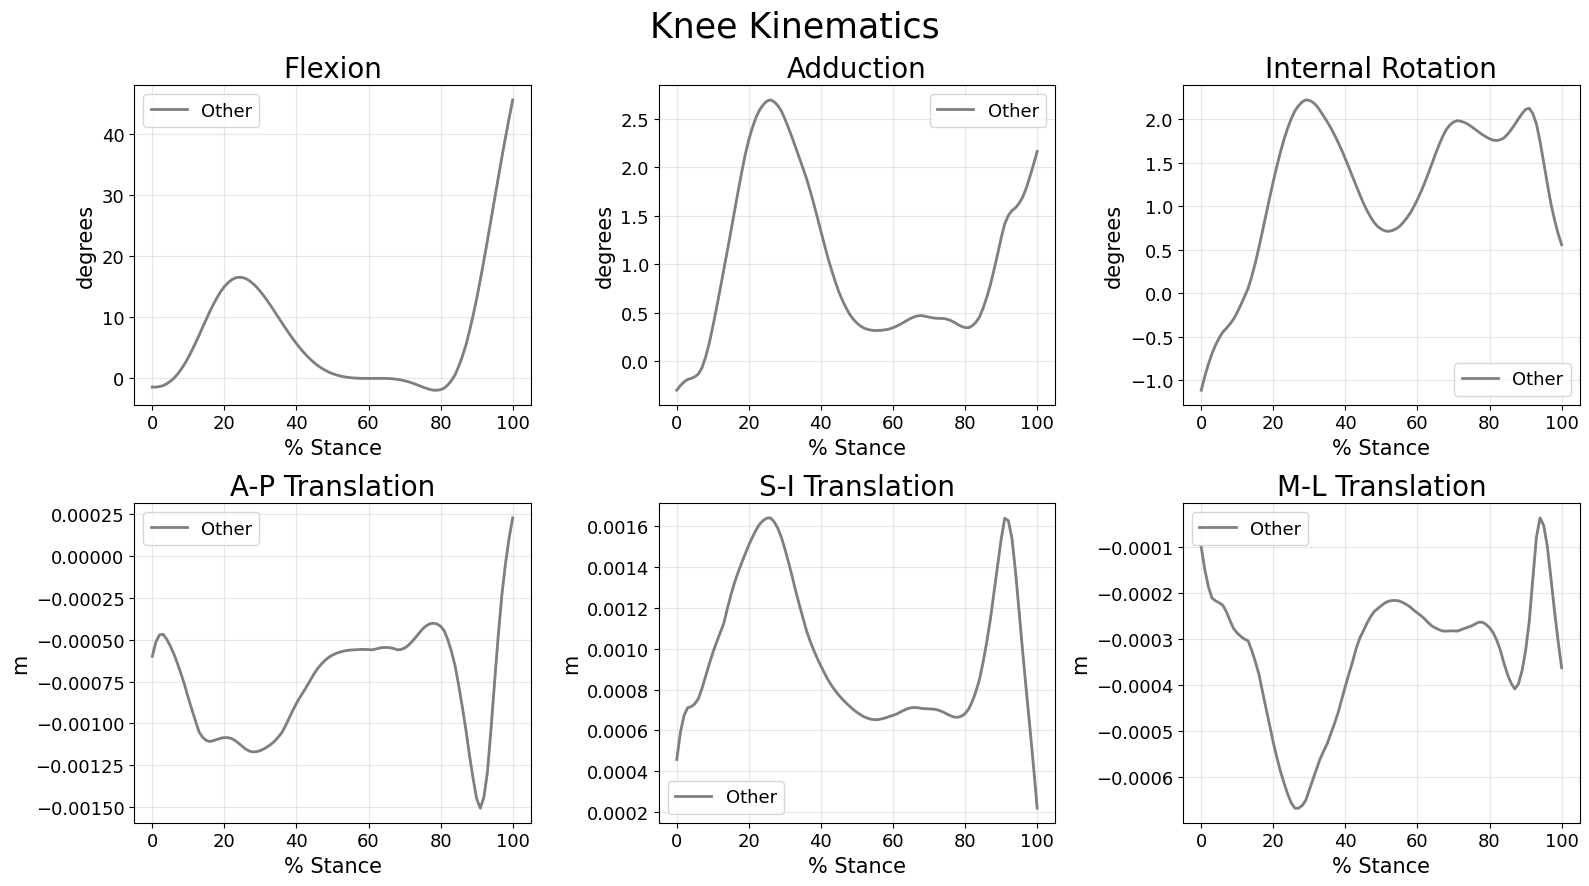

In [3]:
# Knee kinematics
knee_coords = ['knee_flex_r', 'knee_add_r', 'knee_rot_r', 'knee_tx_r', 'knee_ty_r', 'knee_tz_r']

fig, axes = plot_kinematics_panel(
    group_analysis,
    knee_coords,
    plot_type='mean',  # or 'individual' to show individual traces
    figsize=(16, 9),
    fontsize=15,
    suptitle='Knee Kinematics',
    translation_units='m'  # Use 'm' for meters or 'mm' for millimeters
)
plt.show()


**Note:** Translation coordinates (tx, ty, tz) default to meters. Use `translation_units='mm'` to display in millimeters if preferred.


### Patellofemoral Kinematics


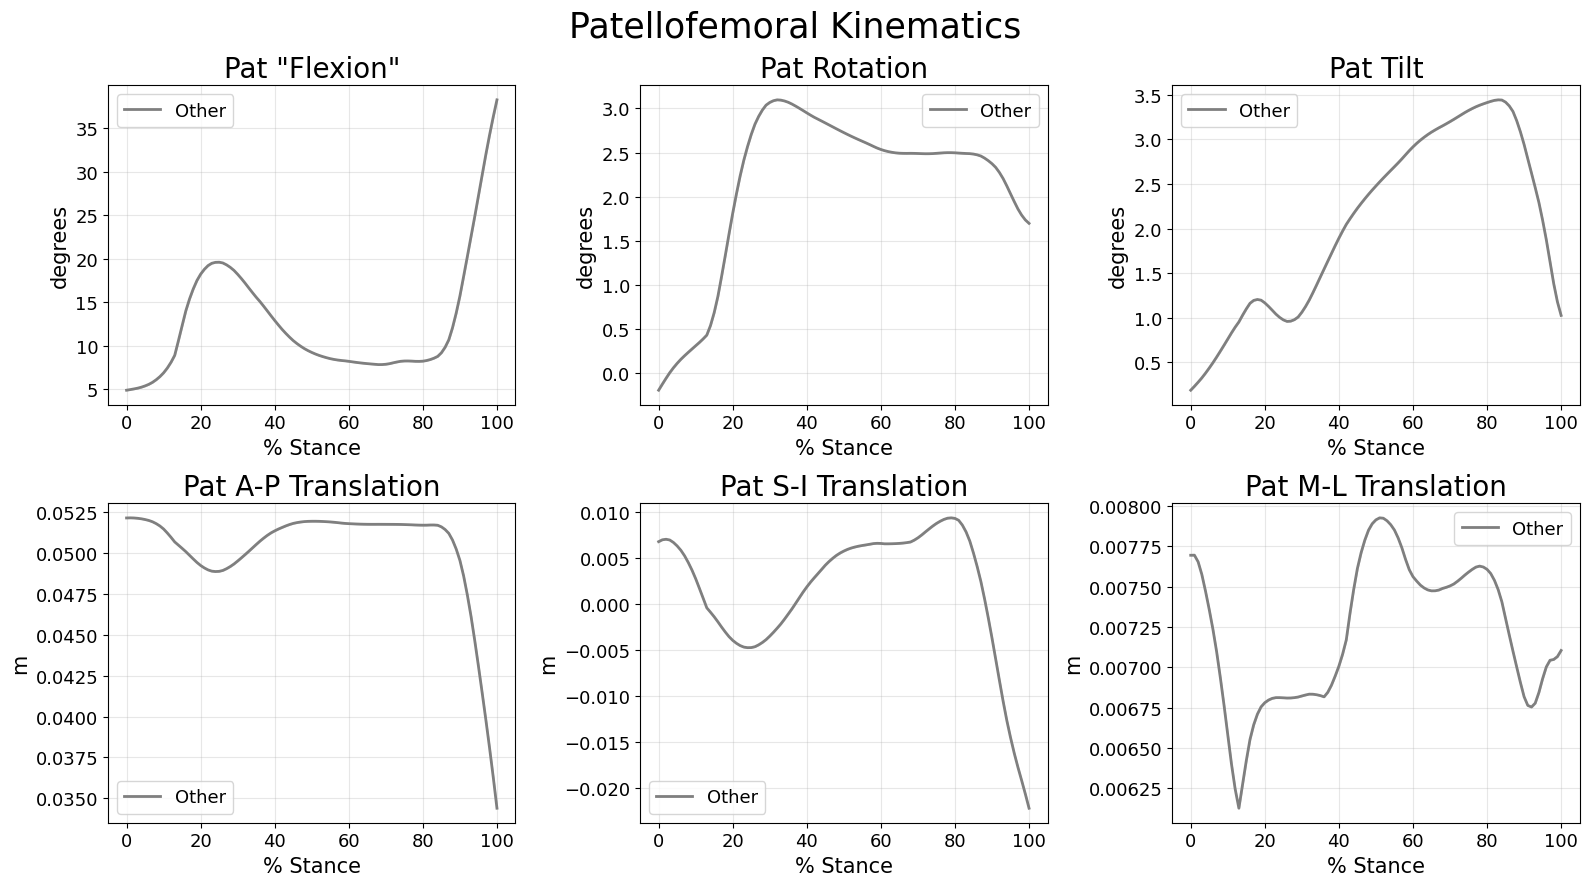

In [4]:
# Patellofemoral kinematics
pf_coords = ['pf_flex_r', 'pf_rot_r', 'pf_tilt_r', 'pf_tx_r', 'pf_ty_r', 'pf_tz_r']

fig, axes = plot_kinematics_panel(
    group_analysis,
    pf_coords,
    plot_type='mean',
    figsize=(16, 9),
    suptitle='Patellofemoral Kinematics'
)
plt.show()


### Spaghetti Plots (Individual Traces)

To see individual subject traces instead of mean±STE, use `plot_type='individual'`.


In [ ]:
# Spaghetti plot - shows individual subject traces
knee_coords = ['knee_flex_r', 'knee_add_r', 'knee_rot_r', 'knee_tx_r', 'knee_ty_r', 'knee_tz_r']

fig, axes = plot_kinematics_panel(
    group_analysis,
    knee_coords,
    plot_type='individual',  # KEY: Use 'individual' for spaghetti plots!
    figsize=(16, 9),
    fontsize=15,
    suptitle='Knee Kinematics - Individual Subjects',
    translation_units='m'
)
plt.show()


## Identify Outlier Subjects

If you notice large confidence intervals or suspect simulation errors (e.g., at the end of stance), 
you can use `identify_outlier_subjects()` to find which subjects are causing the variability.


In [ ]:
# Example: Check for outliers in knee flexion during last 5% of stance
outliers_knee = group_analysis.identify_outlier_subjects(
    coordinate_name='knee_flex_r',
    time_range=(95, 100),  # Last 5% of stance
    threshold_std=2.0  # Flag subjects >2 std from mean
)

# Example: Check for outliers in contact pressure
outliers_pressure = group_analysis.identify_outlier_subjects(
    region=4,  # Medial tibia
    outcome='regional_max_pressure',
    time_range=(95, 100),
    threshold_std=2.0
)

# The results tell you which subjects are outliers
# You can then investigate those subjects individually or remove them

# --- REMOVE OUTLIERS ---

# Option 1: Remove by subject ID (works across all groups)
# group_analysis.remove_subjects(subject_ids=['9003175_RIGHT', '9007456_LEFT'])

# Option 2: Remove by index within a specific group
# group_analysis.remove_subjects(subject_indices=[0, 3], group='healthy')

# Option 3: Automatically remove all identified outliers
# for group_name, outlier_info in outliers_pressure.items():
#     if len(outlier_info['outlier_indices']) > 0:
#         group_analysis.remove_subjects(
#             subject_indices=outlier_info['outlier_indices'],
#             group=group_name
#         )

# After removing, re-run your plots and analyses!


### Custom Spaghetti Plots for Contact Mechanics

For other data types (muscles, contact, ligaments), you can create custom spaghetti plots:


In [ ]:
# Example: Spaghetti plot for medial tibia max pressure
from pycomak.plotting_utils import GROUP_COLORS

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Get individual traces
data = group_analysis.get_regional_contact_data(
    region=4,
    outcome='regional_max_pressure',
    axis='pressure',
    return_individuals=True  # KEY: Get individual traces
)

# Plot each subject
for group_name, group_data in data.items():
    color = GROUP_COLORS.get(group_name, GROUP_COLORS['default'])
    time = np.linspace(0, 100, group_data.shape[1])
    
    for i in range(group_data.shape[0]):
        # Convert to MPa
        pressure_mpa = group_data[i, :] / 1e6
        
        # Label only first trace of each group
        label = group_name.capitalize() if i == 0 else None
        ax.plot(time, pressure_mpa, color=color, alpha=0.5, linewidth=1, label=label)

ax.set_xlabel('% Stance', fontsize=15)
ax.set_ylabel('Max Pressure (MPa)', fontsize=15)
ax.set_title('Medial Tibia Max Pressure - Individual Subjects', fontsize=18)
ax.legend(fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# This makes it easy to spot outliers visually!


## Muscle Forces


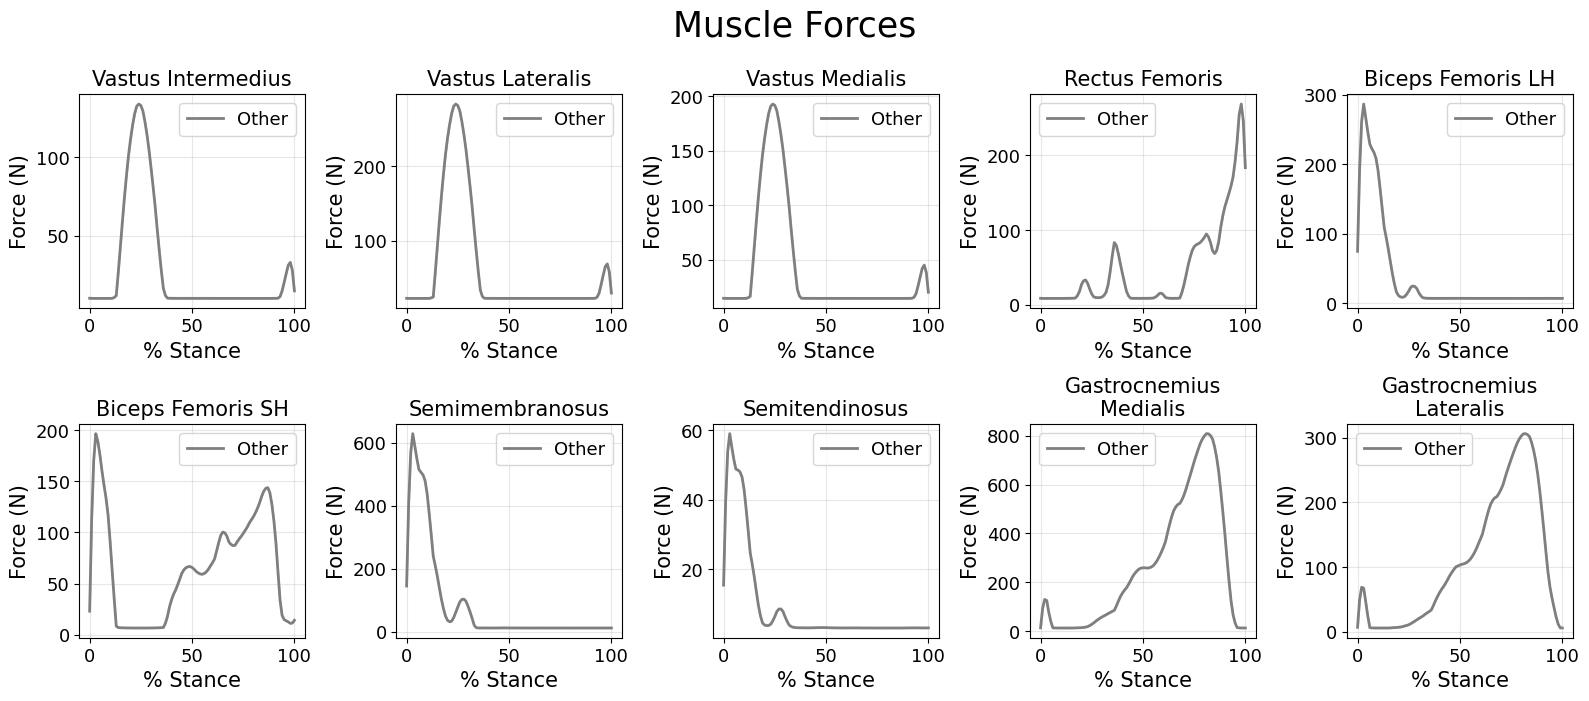

In [5]:
knee_muscles = [
    'vasint_r', 'vaslat_r', 'vasmed_r', 'recfem_r',
    'bflh_r', 'bfsh_r', 'semimem_r', 'semiten_r',
    'gasmed_r', 'gaslat_r'
]

fig, axes = plot_muscles_panel(
    group_analysis,
    knee_muscles,
    outcome='actuation',
    figsize=(16, 7),
    suptitle='Muscle Forces'
)
plt.show()


## Ligament Forces


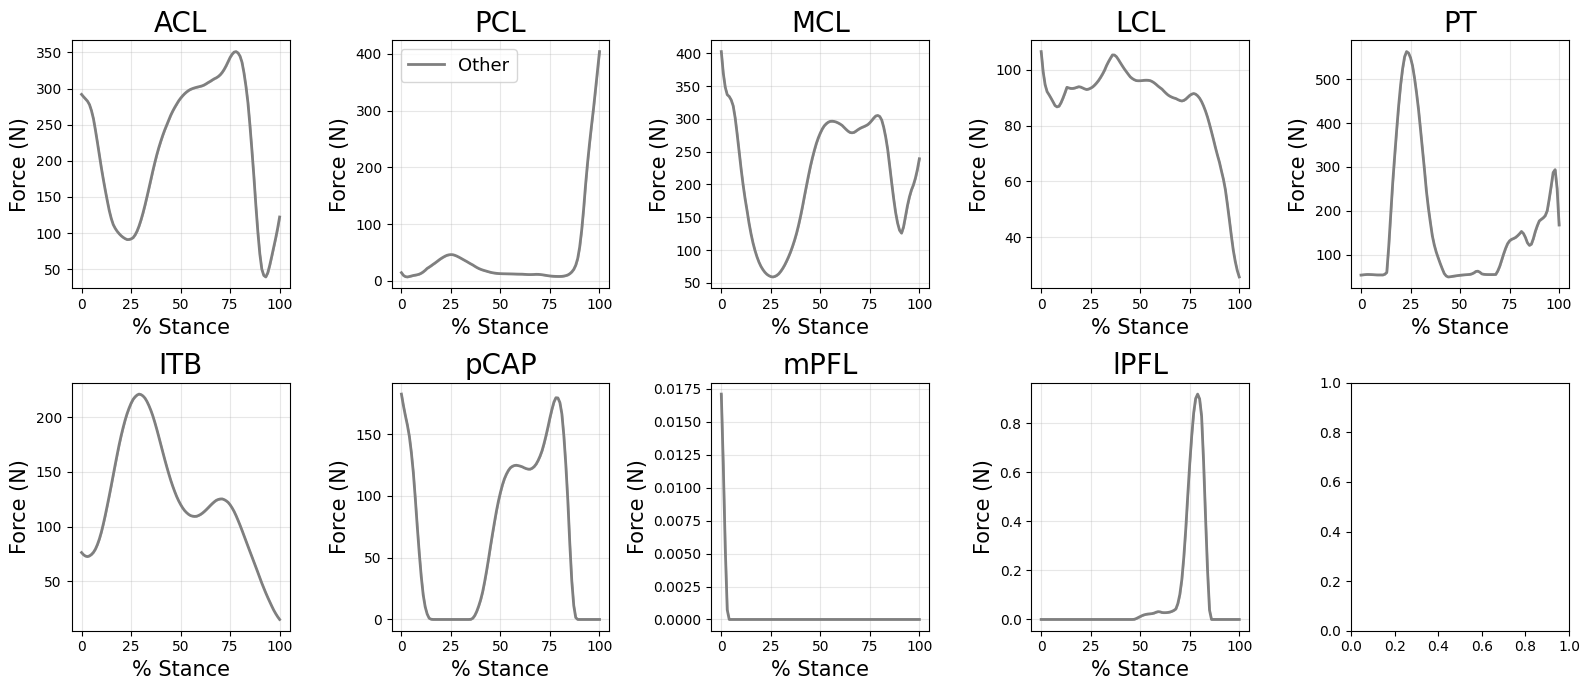

In [6]:
from pycomak.plotting_utils import GROUP_COLORS

ligaments = ['ACL', 'PCL', 'MCL', 'LCL', 'PT', 'ITB', 'pCAP', 'mPFL', 'lPFL']

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()
fontsize = 15

for idx, lig_name in enumerate(ligaments):
    data = group_analysis.get_ligament_data(lig_name, return_individuals=False)
    
    for group_name, group_data in data.items():
        time = group_data['time']
        mean = group_data['mean']
        ste = group_data['ste']
        color = GROUP_COLORS.get(group_name, GROUP_COLORS['default'])
        
        axes[idx].plot(time, mean, label=group_name.capitalize(), color=color, linewidth=2)
        axes[idx].fill_between(time, mean - ste, mean + ste, alpha=0.3, color=color)
    
    axes[idx].set_title(lig_name, fontsize=fontsize + 5)
    axes[idx].set_xlabel('% Stance', fontsize=fontsize)
    axes[idx].set_ylabel('Force (N)', fontsize=fontsize)
    axes[idx].grid(True, alpha=0.3)
    if idx == 1:  # Show legend on second plot
        axes[idx].legend(fontsize=fontsize - 2)

plt.tight_layout()
plt.show()


## Contact Mechanics

### Comprehensive Contact Panel

This creates a multi-panel view of all contact outcomes.


**Region Labels:** The region indices map to anatomical locations:
- Region 4 = Medial Tibia
- Region 5 = Lateral Tibia

These mappings are defined in `plotting_utils.REGION_LABELS` and can be customized if needed.


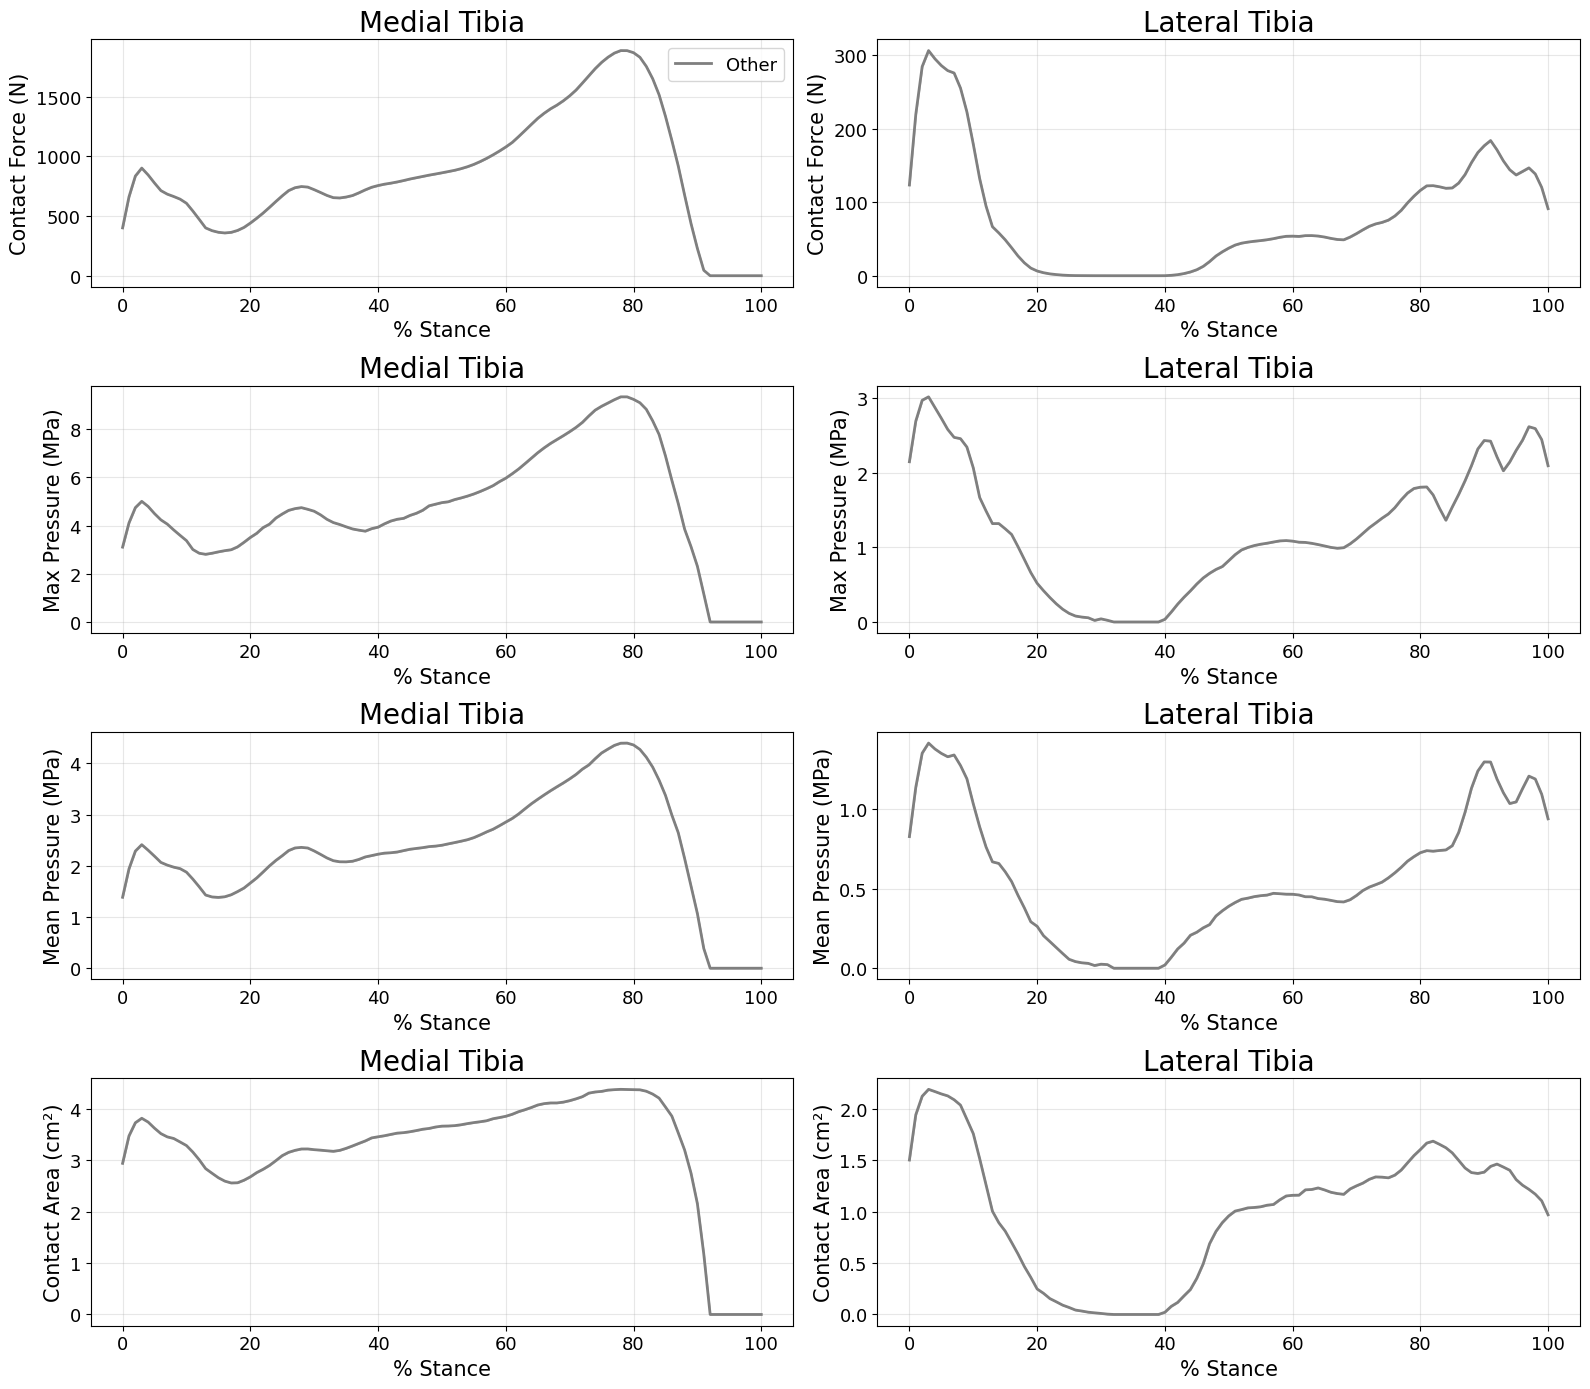

In [7]:
fig, axes = plot_contact_comparison_panel(
    group_analysis,
    regions=[4, 5],  # Medial (4) and lateral (5) tibia
    outcomes=['force', 'max_pressure', 'mean_pressure', 'area'],
    # figsize auto-calculated (3.5 inches per row) - or specify manually like (16, 14)
    fontsize=15
)
plt.show()


### Publication-Ready Figures

Create publication-ready figures for specific contact outcomes.


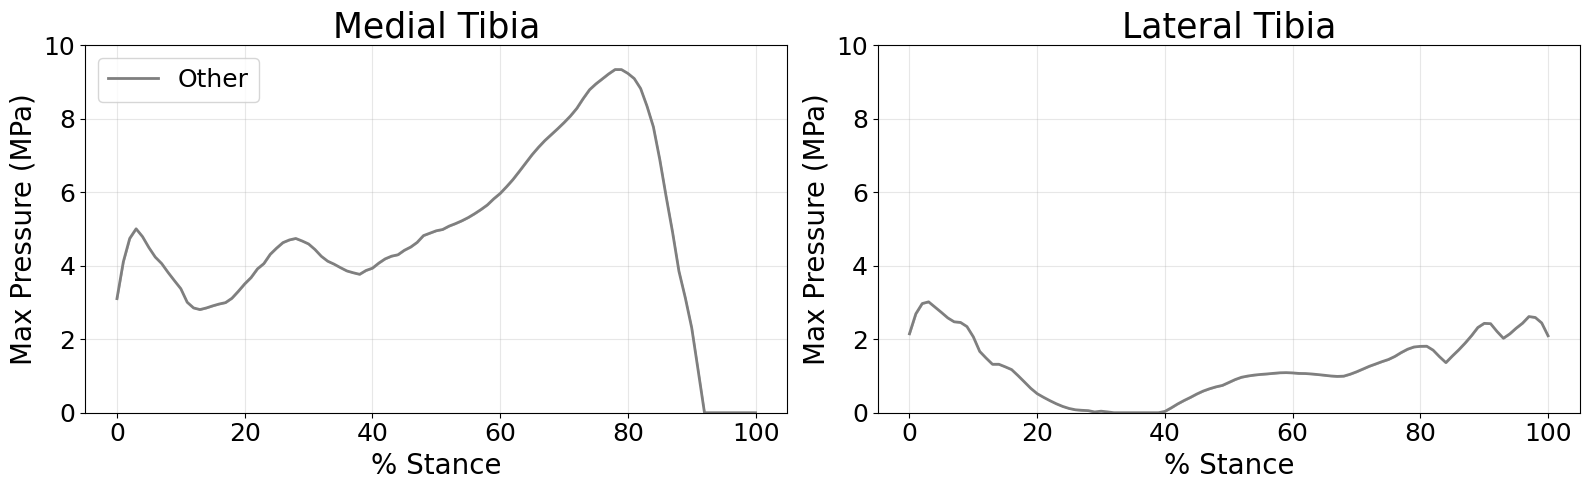

In [8]:
# Max pressure figure
fig, axes = create_publication_figure(
    group_analysis,
    regions=[4, 5],
    outcome_type='max_pressure',
    figsize=(16, 5),
    fontsize=20,
    ylim=(0, 10)
)
plt.show()


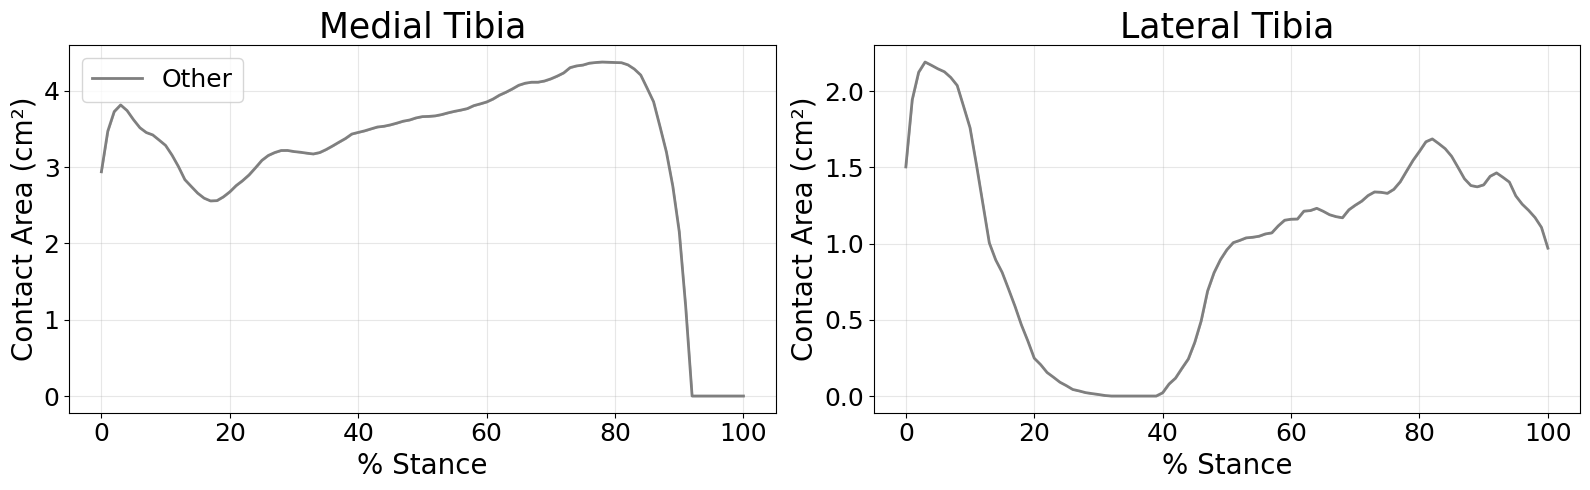

In [9]:
# Contact area figure
fig, axes = create_publication_figure(
    group_analysis,
    regions=[4, 5],
    outcome_type='area',
    figsize=(16, 5),
    fontsize=20
)
plt.show()


## Export Data for Statistical Analysis

### Extract Peak Values

For statistical testing, you often need summary metrics like peak values.


In [10]:
# Extract peak pressures for each subject
outcome_data = {}

for region in [4, 5]:  # Medial and lateral
    region_name = 'medial' if region == 4 else 'lateral'
    data = group_analysis.get_regional_contact_data(
        region=region,
        outcome='regional_max_pressure',
        axis='pressure',
        return_individuals=True
    )
    
    for group_name, group_data in data.items():
        # Get peak pressure for each subject (convert to MPa)
        peak_pressures = np.max(group_data, axis=1) / 1e6
        
        if group_name not in outcome_data:
            outcome_data[group_name] = {}
        
        outcome_data[group_name][f'{region_name}_peak_pressure'] = peak_pressures

# Create DataFrame for export
export_data = []
for group_name, data in outcome_data.items():
    n_subjects = len(data['medial_peak_pressure'])
    for i in range(n_subjects):
        export_data.append({
            'group': group_name,
            'subject_idx': i,
            'medial_peak_pressure_MPa': data['medial_peak_pressure'][i],
            'lateral_peak_pressure_MPa': data['lateral_peak_pressure'][i]
        })

export_df = pd.DataFrame(export_data)
print("Peak Pressures Summary:")
print(export_df.groupby('group')[['medial_peak_pressure_MPa', 'lateral_peak_pressure_MPa']].describe())

# Save to CSV for statistical analysis in R, SPSS, etc.
# export_df.to_csv('peak_pressures_for_stats.csv', index=False)


Peak Pressures Summary:
      medial_peak_pressure_MPa                                              \
                         count      mean std       min       25%       50%   
group                                                                        
other                      1.0  9.340783 NaN  9.340783  9.340783  9.340783   

                          lateral_peak_pressure_MPa                          \
            75%       max                     count      mean std       min   
group                                                                         
other  9.340783  9.340783                       1.0  3.017695 NaN  3.017695   

                                               
            25%       50%       75%       max  
group                                          
other  3.017695  3.017695  3.017695  3.017695  


### Extract Time Series Data

For SPM (Statistical Parametric Mapping) or other time-series analyses, export the full waveforms.


In [11]:
# Example: Export full time series for SPM analysis
coord_data = group_analysis.get_coordinate_data('knee_add_r', return_individuals=True)

for group_name, data in coord_data.items():
    # data is shape (n_subjects, n_timesteps)
    df = pd.DataFrame(data.T)  # Transpose so columns are subjects
    df.columns = [f'subject_{i}' for i in range(data.shape[0])]
    df['time_pct'] = np.linspace(0, 100, data.shape[1])
    
    # Save to CSV
    # df.to_csv(f'knee_adduction_{group_name}_timeseries.csv', index=False)
    
    print(f"{group_name}: {data.shape[0]} subjects, {data.shape[1]} time points")


other: 1 subjects, 101 time points


### Contact Mechanics - Individual Traces (Spaghetti Plots)

To see individual subject traces for contact mechanics, create a custom panel:


In [ ]:
# Create spaghetti plot panel for contact mechanics
from pycomak.plotting_utils import GROUP_COLORS, REGION_LABELS

regions = [4, 5]  # Medial and lateral
outcomes = ['force', 'max_pressure', 'mean_pressure', 'area']

# Outcome mapping
outcome_map = {
    'force': 'regional_contact_force',
    'max_pressure': 'regional_max_pressure', 
    'mean_pressure': 'regional_mean_pressure',
    'area': 'regional_contact_area'
}

axis_map = {
    'force': 'norm',
    'max_pressure': 'pressure',
    'mean_pressure': 'pressure', 
    'area': 'area'
}

ylabel_map = {
    'force': 'Contact Force (N)',
    'max_pressure': 'Max Pressure (MPa)',
    'mean_pressure': 'Mean Pressure (MPa)',
    'area': 'Contact Area (cm²)'
}

# Create panel
n_rows = len(outcomes)
n_cols = len(regions)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 3.5*n_rows))

for row_idx, outcome_type in enumerate(outcomes):
    for col_idx, region in enumerate(regions):
        ax = axes[row_idx, col_idx]
        
        # Get individual traces
        data = group_analysis.get_regional_contact_data(
            region=region,
            outcome=outcome_map[outcome_type],
            axis=axis_map[outcome_type],
            return_individuals=True
        )
        
        # Plot each subject
        for group_name, group_data in data.items():
            color = GROUP_COLORS.get(group_name, GROUP_COLORS['default'])
            time = np.linspace(0, 100, group_data.shape[1])
            
            for i in range(group_data.shape[0]):
                # Convert units
                if 'pressure' in outcome_type:
                    plot_data = group_data[i, :] / 1e6  # Pa to MPa
                elif outcome_type == 'area':
                    plot_data = group_data[i, :] * 1e4  # m² to cm²
                else:
                    plot_data = group_data[i, :]
                
                # Label only first trace of each group
                label = group_name.capitalize() if i == 0 else None
                ax.plot(time, plot_data, color=color, alpha=0.5, linewidth=1, label=label)
        
        # Formatting
        ax.set_title(REGION_LABELS.get(region, f'Region {region}'), fontsize=15)
        ax.set_xlabel('% Stance', fontsize=13)
        ax.set_ylabel(ylabel_map[outcome_type], fontsize=13)
        ax.grid(True, alpha=0.3)
        
        # Legend only on first subplot
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


**Simpler version** - Just max pressure for medial and lateral:


In [ ]:
# Simpler: just max pressure, medial and lateral
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, (region, region_name) in enumerate([(4, 'Medial Tibia'), (5, 'Lateral Tibia')]):
    # Get individual traces
    data = group_analysis.get_regional_contact_data(
        region=region,
        outcome='regional_max_pressure',
        axis='pressure',
        return_individuals=True
    )
    
    # Plot each subject
    for group_name, group_data in data.items():
        color = GROUP_COLORS.get(group_name, GROUP_COLORS['default'])
        time = np.linspace(0, 100, group_data.shape[1])
        
        for i in range(group_data.shape[0]):
            pressure_mpa = group_data[i, :] / 1e6  # Convert to MPa
            label = group_name.capitalize() if i == 0 else None
            axes[idx].plot(time, pressure_mpa, color=color, alpha=0.5, linewidth=1, label=label)
    
    axes[idx].set_title(region_name, fontsize=18)
    axes[idx].set_xlabel('% Stance', fontsize=15)
    axes[idx].set_ylabel('Max Pressure (MPa)', fontsize=15)
    axes[idx].grid(True, alpha=0.3)
    if idx == 0:
        axes[idx].legend(fontsize=13)

plt.tight_layout()
plt.show()


## Summary

This notebook demonstrated how to:
1. **Load subjects** into groups using `GroupJamAnalysis`
2. **Extract data** for kinematics, muscle forces, ligament forces, and contact mechanics
3. **Create visualizations** using the plotting utilities
4. **Export data** for statistical analysis

### Key Advantages

- **No more copy-paste**: Reusable functions eliminate code duplication
- **Consistent analysis**: Same methods work for 1 subject or 100 subjects
- **Easy group comparisons**: Built-in support for multiple groups
- **Well-documented**: Comprehensive docstrings guide usage
- **Flexible**: Get individual traces or statistical summaries
- **Publication-ready**: Standardized, customizable plots

### Next Steps

- Add more subjects to your analysis
- Customize plots by modifying colors, fonts, or layouts
- Extract additional outcomes (e.g., joint moments, muscle lengths)
- Perform statistical tests on the exported data
- Create custom analyses using the extracted data arrays
